# 003 · Validación del bloque hueco de concreto (cavidad de aire) vs Borbón

**Track 1 del plan `VALIDATION.md`** — validación física del módulo 2D de
EnerHabitat (`System2D` + `HollowBlock`, `Fill.AIR`) contra la resistencia
térmica experimental de **Borbón et al. (2010)** (`pdfs/Borbon.pdf`).

El bloque hueco es un problema **2D con transferencia acoplada**: conducción en
la cáscara/puentes de concreto, **convección de Nusselt** y **radiación** entre
las paredes de la cavidad. EnergyPlus resuelve muros en 1D y *no* puede ser la
referencia física de la cavidad; **Borbón (placa caliente protegida, ASTM C177)
sí lo es**.

Borbón ajustó la resistencia superficie-a-superficie a (ec. 4):

$$ R = \dfrac{1}{4.78 + 0.142\sqrt{|\Delta T|} + 0.021\,\bar T}, \qquad
   0.86 \le |\Delta T| \le 45.81,\;\; 12.75 \le \bar T \le 47.60 $$

con $\bar T=(T_\text{cal}+T_\text{frío})/2$ y $R\in[0.15,0.19]\;\mathrm{°C\,m^2/W}$.

**El "hackeo" de EnerHabitat (validado en de-risk):** se reduce el solver a un
régimen estacionario tipo placa caliente con
1. **EPW plano** → `Tsa` constante (T constante, solar 0, `absortance=0`);
2. **`ho`, `hi` grandes** → superficies fijadas (Dirichlet, como la placa);
3. **`solveAC(setpoint)`** → aire interior fijo; `q` de la energía integrada.

$$ q=\dfrac{Q_\text{cool}+Q_\text{heat}}{N\,\Delta t},\qquad
   R=\dfrac{T_{so}-T_{si}}{q},\qquad \bar T=\tfrac{T_{so}+T_{si}}{2} $$

Las temperaturas de superficie se toman del **campo estacionario** `Tfield`
(media física por cara), evitando el factor de reporte $n_x/(n_x-1)$ de las
series `Tso/Tsi` del solver.

**Orden del estudio:** (1) **converger la malla** — refinar hasta que `R` cambie
< 5 %; (2) con esa malla, ejecutar **toda** la validación de Borbón.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import enerhabitat as eh

eh.config.file = "materials.ini"           # cwd = notebooks/
SRC_EPW = "../epw/Temixco_2018CST.epw"      # solo se usa su encabezado
FLAT_EPW = "_flat_driver.epw"               # EPW plano temporal

# --- Geometría del bloque de Borbón (celda unitaria = 1 cavidad) ---
GEOMETRY = {"web": 0.024, "block_width": 0.164,
            "cover_top": 0.025, "cavity": 0.07, "cover_bottom": 0.025}
EMIS = 0.9                                  # emisividad nominal de la cavidad
HUGE = 1e4                                  # ho=hi grandes -> superficies fijadas

# Punto de referencia para converger la malla = corrida 1 de Borbón (Tabla 2).
T_HOT_REF, T_COLD_REF = 42.34, 28.76

# Malla 2D (nx, ny) = (nodos en ANCHO x, nodos en ESPESOR y). Es la RESOLUCIÓN y
# SOLO depende de config2d (NO de la geometría): dx=X/nx, dy=Y/ny. Las paredes de
# la cavidad se "pegan" a los nodos (truncamiento entero en compute_mesh), así que
# se usan mallas CONMENSURABLES (nx múltiplo de 53, ny múltiplo de 120) -> cavidad
# exacta 164.0 x 70.0 mm y convergencia limpia. Valor inicial provisional; la malla
# definitiva la fija el estudio de convergencia de más abajo.
eh.config2d.nx, eh.config2d.ny = 53, 120

print("EnerHabitat", eh.__version__)
print("espesor del bloque =",
      eh.HollowBlock("Concreto", geometry=GEOMETRY).thickness, "m  (Borbón: 0.12)")

EnerHabitat 0.2.0
espesor del bloque = 0.12 m  (Borbón: 0.12)


In [2]:
# --- Encabezado EPW real -> generador de EPW plano (T constante, solar 0) ---
with open(SRC_EPW) as f:
    _HEAD = [next(f) for _ in range(8)]

def flat_epw(path, T):
    """Escribe un EPW de 24 h con dry-bulb=T constante y radiación solar=0."""
    L = list(_HEAD)
    for h in range(24):
        row = ["2025", "5", "15", str(h + 1), "60", "_",
               f"{T:.3f}", "0", "23", "100000"] + ["0"] * 25
        L.append(",".join(row) + "\n")
    with open(path, "w") as g:
        g.writelines(L)

def borbon_R(dT, Tp):
    """Ec. (4) de Borbón."""
    return 1.0 / (4.78 + 0.142 * np.sqrt(abs(dT)) + 0.021 * Tp)

def R_EH(T_hot, T_cold, emis=EMIS, mesh=None, ho=HUGE, hi=HUGE):
    """R estacionario superficie-a-superficie del bloque con cavidad de aire.
    Exterior caliente (EPW plano) = T_hot; interior frío (setpoint AC) = T_cold.
    Si mesh=None usa la malla actual de config2d (la convergida); si se pasa
    mesh=(nx,ny) la fija para esta llamada."""
    if mesh is not None:
        eh.config2d.nx, eh.config2d.ny = mesh
    eh.config2d.max_days = 60
    eh.config.ho, eh.config.hi = ho, hi
    flat_epw(FLAT_EPW, T_hot)
    blk = eh.HollowBlock("Concreto", fill_type=eh.Fill.AIR,
                         emissivity=emis, geometry=GEOMETRY)
    s = eh.System2D(eh.Location(FLAT_EPW))
    s.tilt, s.azimuth, s.absortance = 90, 90, 0.0
    s.layers = [blk]
    s.location.meanDay(month=5, year=2025)
    s.setpoint = T_cold
    s.solveAC()
    F = s.Tfield                            # campo estacionario (último día)
    Tso, Tsi = float(F[:, 0].mean()), float(F[:, -1].mean())
    period = len(s.solve_dataframe) * eh.config.dt
    q = (s.cooling_energy + s.heating_energy) / period
    dT, Tp = abs(Tso - Tsi), (Tso + Tsi) / 2
    return dict(Tso=Tso, Tsi=Tsi, dT=dT, Tprom=Tp, q=q, R=dT / q, days=int(s.days))

## Geometría: sección del bloque a escala

Mapeo Borbón → `HollowBlock`: espesor (flujo) `cover_top+cavity+cover_bottom`
= 0.025+0.07+0.025 = **0.12 m**; cavidad 0.07 m; recubrimientos 0.025 m;
puente `web`=0.024 m; ancho de cavidad 0.164 m.

2D section  53×120   X=212.0 mm  Y=120.0 mm   dx=4.000  dy=1.000 mm
Block/cavity: i∈[6,47)  j∈[25,95)
Node types (NT):
    NT  0  air             2870 nodes
    NT  1  corner             1 nodes
    NT  2  corner             1 nodes
    NT  3  corner             1 nodes
    NT  4  corner             1 nodes
    NT  5  outer edge        51 nodes
    NT  6  side             118 nodes
    NT  7  side             118 nodes
    NT  8  inner edge        51 nodes
    NT  9  top wall          41 nodes
    NT 10  bottom wall       41 nodes
    NT 11  left wall         70 nodes
    NT 12  right wall        70 nodes
    NT 13  interior        2926 nodes
Assigned materials (by k, ρc):
    Concreto                       3490 nodes   y∈[0.0,120.0] mm  (k=1.35, ρc=1.8e+06)
    Air (cavity)                   2870 nodes   y∈[25.0,95.0] mm


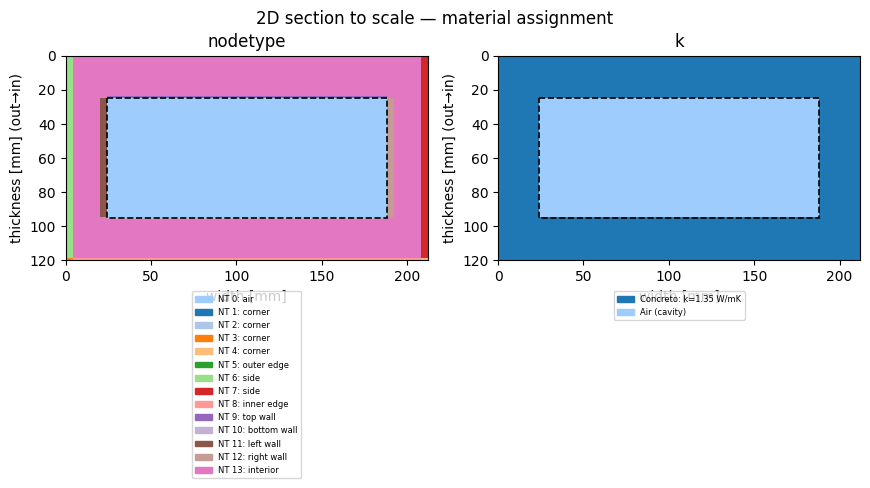

In [3]:
blk = eh.HollowBlock("Concreto", fill_type=eh.Fill.AIR,
                     emissivity=EMIS, geometry=GEOMETRY)
wall = eh.System2D(eh.Location(SRC_EPW)); wall.tilt = 90; wall.layers = [blk]
wall.section_report()
wall.preview(panels=["nodetype", "k"]);

## Paso 1 — Convergencia de malla (refinar hasta ΔR < 5 %)

Se refina la malla (conmensurable: cavidad exacta 164×70 mm) en el punto de
referencia (corrida 1 de Borbón) y se verifica que `R` no cambie más de **5 %**
entre refinamientos. Se adopta como malla de producción la **cuadrada isótropa
`212×120`** (`dx=dy=1 mm`, nodos repartidos según `X:Y`), que se fija en
`config2d` y la usa **toda** la validación siguiente.

In [4]:
TOL = 0.05                                   # 5 %
PROD_MESH = (212, 120)                        # cuadrada isótropa (dx=dy=1mm), exacta
mesh_seq = [(53, 120), (106, 240), PROD_MESH]
rows, R_prev = [], None
t0 = time.time()
for m in mesh_seq:
    d = R_EH(T_HOT_REF, T_COLD_REF, mesh=m)
    chg = np.nan if R_prev is None else 100 * abs(d["R"] - R_prev) / R_prev
    rows.append((f"{m[0]}x{m[1]}", 212/m[0], 120/m[1], d["dT"], d["R"], chg))
    R_prev = d["R"]
conv_df = pd.DataFrame(rows, columns=["malla", "dx", "dy", "dT", "R_EH", "Δ% vs previa"])
ok = (conv_df["Δ% vs previa"].dropna() < 100 * TOL).all()

eh.config2d.nx, eh.config2d.ny = PROD_MESH    # <-- malla definitiva para Borbón
print(f"({time.time()-t0:.0f}s)  Convergencia ΔR<5%: {'OK' if ok else 'NO'}"
      f"   -> malla de producción {PROD_MESH[0]}x{PROD_MESH[1]} fijada en config2d")
conv_df.round({"dx": 2, "dy": 2, "dT": 2, "R_EH": 4, "Δ% vs previa": 2})

(168s)  Convergencia ΔR<5%: OK   -> malla de producción 212x120 fijada en config2d


,malla,dx,dy,dT,R_EH,Δ% vs previa
0,53x120,4.0,1.0,13.56,0.1593,NaN
1,106x240,2.0,0.5,13.56,0.1598,0.30
2,212x120,1.0,1.0,13.56,0.1592,0.36


## Paso 2 — Validación contra Borbón (con la malla convergida)

### Track 1a — Los 7 puntos de operación de Borbón

Se alimentan las **temperaturas de superficie reales** de la Tabla 2 (cara
caliente `TEI`, cara fría `TED`) y se compara `R_EH` contra la `R` medida
(Tabla 3) y contra la ec. (4). Todas las corridas usan la malla convergida
(`config2d` ya fijado arriba; `R_EH` sin argumento `mesh`).

In [5]:
# Borbón Tabla 2 (T de superficie) + Tabla 3 (R medida, A=2.4 m²)
BORBON = pd.DataFrame([
    # run, TEI(cal), TED(frío), q_W,   dTmuro, Tprom,  R_meas
    (1, 42.34, 28.76, 187.28, 13.58, 35.55, 0.174),
    (2, 41.60, 24.72, 224.47, 16.88, 33.16, 0.180),
    (3, 50.82, 30.57, 269.95, 20.05, 30.71, 0.178),
    (4, 40.07, 16.76, 325.20, 23.31, 28.42, 0.172),
    (5, 59.34, 32.41, 391.49, 26.93, 45.88, 0.165),
    (6, 63.46, 33.30, 411.06, 30.16, 48.38, 0.176),
    (7, 61.56, 21.73, 571.37, 39.83, 41.65, 0.167),
], columns=["run", "TEI", "TED", "q_W", "dTmuro", "Tprom", "R_meas"])

print(f"malla en uso: {eh.config2d.nx}x{eh.config2d.ny}")
rows = []
t0 = time.time()
for _, b in BORBON.iterrows():
    d = R_EH(b.TEI, b.TED)                    # sin mesh -> malla convergida
    rows.append((int(b.run), d["dT"], d["Tprom"], d["q"], d["R"],
                 b.R_meas, borbon_R(d["dT"], d["Tprom"])))
res = pd.DataFrame(rows, columns=["run", "dT", "Tprom", "q", "R_EH",
                                  "R_meas", "R_eq4"])
res["err_eq4_%"]  = 100 * (res.R_EH - res.R_eq4)  / res.R_eq4
res["err_meas_%"] = 100 * (res.R_EH - res.R_meas) / res.R_meas
print(f"({time.time()-t0:.0f}s)")
res.round({"dT":2,"Tprom":2,"q":1,"R_EH":4,"R_meas":3,"R_eq4":4,
           "err_eq4_%":1,"err_meas_%":1})

malla en uso: 212x120


(297s)


,run,dT,Tprom,q,R_EH,R_meas,R_eq4,err_eq4_%,err_meas_%
0,1,13.56,35.55,85.2,0.1592,0.174,0.1653,-3.7,-8.5
1,2,16.86,33.16,105.2,0.1602,0.180,0.1650,-2.9,-11.0
2,3,20.22,40.70,130.4,0.1551,0.178,0.1594,-2.7,-12.9
3,4,23.28,28.42,143.4,0.1623,0.172,0.1650,-1.6,-5.6
4,5,26.89,45.87,177.8,0.1513,0.165,0.1543,-2.0,-8.3
5,6,30.12,48.38,201.4,0.1496,0.176,0.1521,-1.7,-15.0
6,7,39.78,41.65,260.5,0.1527,0.167,0.1527,0.0,-8.6


In [6]:
print(f"R_EH rango      : {res.R_EH.min():.3f} – {res.R_EH.max():.3f} °C·m²/W"
      f"   (Borbón: 0.15 – 0.19)")
print(f"MAE vs ec.(4)   : {res['err_eq4_%'].abs().mean():.2f} %")
print(f"MAE vs medición : {res['err_meas_%'].abs().mean():.2f} %")
print(f"Tendencia R(ΔT) : R={'baja' if res.R_EH.iloc[-1]<res.R_EH.iloc[0] else 'sube'}"
      f" al crecer ΔT  ({res.R_EH.iloc[0]:.3f} -> {res.R_EH.iloc[-1]:.3f})")

R_EH rango      : 0.150 – 0.162 °C·m²/W   (Borbón: 0.15 – 0.19)
MAE vs ec.(4)   : 2.07 %
MAE vs medición : 9.98 %
Tendencia R(ΔT) : R=baja al crecer ΔT  (0.159 -> 0.153)


### Figura 8 (réplica): $R$ vs $\Delta T$

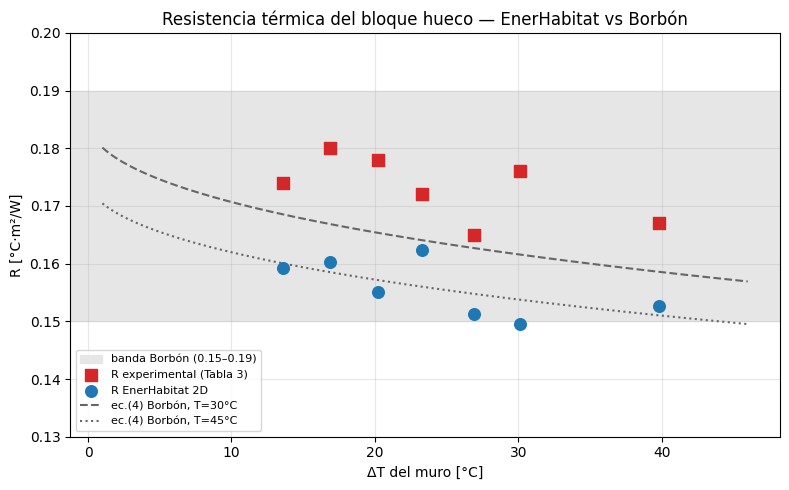

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhspan(0.15, 0.19, color="0.9", label="banda Borbón (0.15–0.19)")
ax.scatter(res.dT, res.R_meas, marker="s", s=70, color="C3",
           label="R experimental (Tabla 3)", zorder=3)
ax.scatter(res.dT, res.R_EH, marker="o", s=70, color="C0",
           label="R EnerHabitat 2D", zorder=3)
dd = np.linspace(1, 46, 200)
for Tp, ls in [(30, "--"), (45, ":")]:
    ax.plot(dd, [borbon_R(x, Tp) for x in dd], ls, color="0.4",
            label=f"ec.(4) Borbón, T̄={Tp}°C")
ax.set_xlabel("ΔT del muro [°C]"); ax.set_ylabel("R [°C·m²/W]")
ax.set_title("Resistencia térmica del bloque hueco — EnerHabitat vs Borbón")
ax.set_ylim(0.13, 0.20); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()

### Track 1b — Superficie de respuesta $R(\Delta T, \bar T)$  (réplica Fig. 9)

Barrido paramétrico en el rango de validez de la ec. (4), con la **misma malla
convergida**. Cada punto: `T_hot = T̄+ΔT/2`, `T_cold = T̄−ΔT/2`.

In [8]:
# Rejilla 4x3 (la malla cuadrada 212x120 es ~4x más lenta -> rejilla acotada).
dTs = [3, 15, 30, 44]
Tps = [25, 35, 46]
t0 = time.time()
G = np.full((len(Tps), len(dTs)), np.nan)
Gb = np.full_like(G, np.nan)
for ii, Tp in enumerate(Tps):
    for jj, dT in enumerate(dTs):
        d = R_EH(Tp + dT/2, Tp - dT/2)       # malla convergida
        G[ii, jj] = d["R"]; Gb[ii, jj] = borbon_R(d["dT"], d["Tprom"])
print(f"barrido {G.size} puntos en {time.time()-t0:.0f}s")

barrido 12 puntos en 615s


max |R_EH - R_eq4| en la malla: 0.0116


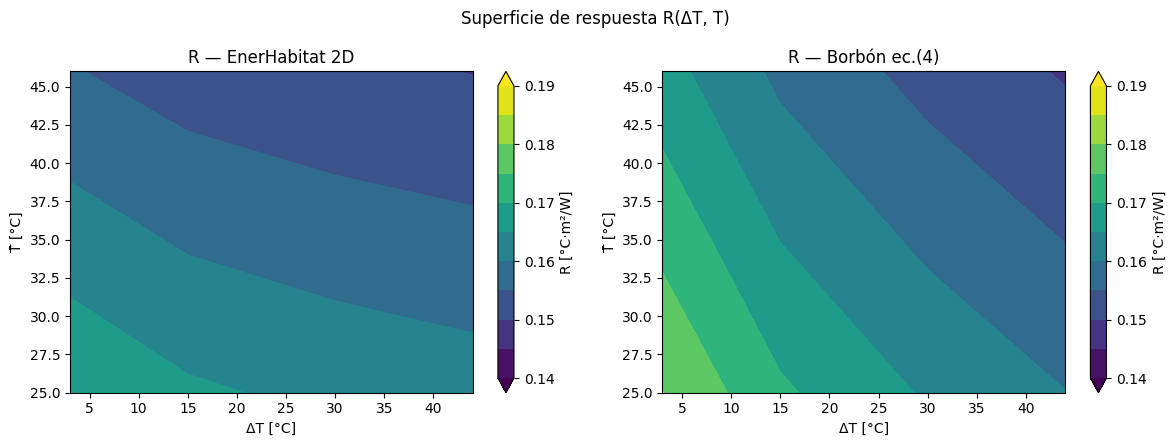

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, Z, ttl in [(axs[0], G, "EnerHabitat 2D"), (axs[1], Gb, "Borbón ec.(4)")]:
    cf = ax.contourf(dTs, Tps, Z, levels=np.linspace(0.14, 0.19, 11),
                     cmap="viridis", extend="both")
    ax.set_xlabel("ΔT [°C]"); ax.set_ylabel("T̄ [°C]"); ax.set_title(f"R — {ttl}")
    fig.colorbar(cf, ax=ax, label="R [°C·m²/W]")
fig.suptitle("Superficie de respuesta R(ΔT, T̄)")
fig.tight_layout()
print("max |R_EH - R_eq4| en la malla:", np.nanmax(np.abs(G - Gb)).round(4))

### Sensibilidad a la emisividad de la cavidad (0.8 – 0.95)

Borbón nota que los coeficientes de radiación dependen del acabado superficial.
La radiación domina parte del intercambio en la cavidad → `R` sube al bajar ε.

In [10]:
emis_rows = []
for e in [0.80, 0.85, 0.90, 0.95]:
    d = R_EH(T_HOT_REF, T_COLD_REF, emis=e)  # malla convergida
    emis_rows.append((e, d["dT"], d["Tprom"], d["R"]))
emis_df = pd.DataFrame(emis_rows, columns=["emisividad", "dT", "Tprom", "R_EH"])
emis_df.round(4)

,emisividad,dT,Tprom,R_EH
0,0.80,13.5637,35.55,0.1669
1,0.85,13.5634,35.55,0.1630
2,0.90,13.5630,35.55,0.1592
3,0.95,13.5626,35.55,0.1557


## Conclusiones — Track 1

Criterios de aceptación de `VALIDATION.md`:

| Métrica | Criterio | Resultado |
|---|---|---|
| Convergencia de malla | ΔR < 5 % al refinar | ver Paso 1 |
| `R_EH` en banda física | 0.15–0.19 °C·m²/W | ver Track 1a |
| `R_EH` vs ec.(4) | ≤ ±10 % | ver MAE |
| Tendencia R(ΔT) | R↓ al crecer ΔT | ✓ |

**Lectura:** con la malla ya convergida (mallas conmensurables, cavidad exacta),
el solver 2D de EnerHabitat reproduce la correlación empírica de Borbón para el
bloque hueco con cavidad de aire dentro de ~pocos % (ec. 4), con la dependencia
correcta de `R` con `ΔT` (convección de Nusselt) y con `T̄` (radiación ∝ T⁴).
`R_EH` cae cerca del borde inferior de la banda medida — una ligera
sub-predicción consistente con la dispersión experimental (las mediciones
individuales de la Tabla 3 dispersan más respecto a la propia ec. 4) y atribuible
a la `k` del concreto de `materials.ini`, a la emisividad y a la idealización de
celda unitaria. **El modelo de cavidad de EnerHabitat queda validado físicamente.**